In [10]:
import sys
sys.path.append('../src')

import pandas as pd
from snowflake_connect import get_connection

# Connect to Snowflake
conn = get_connection()

# Pull data from the view
query = """
    SELECT 
        COMPLAINT_ID,
        PRODUCT,
        COMPLAINT_NARRATIVE,
        CHURN_LABEL
    FROM CHURN_RISK_COMPLAINTS
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Shape: {df.shape}")
print(df['CHURN_LABEL'].value_counts())

/var/folders/cg/b1tx75r52j1_3jtxf4xjchdr0000gn/T/ipykernel_42718/682142365.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Shape: (549893, 4)
CHURN_LABEL
At Risk     350758
Retained    199135
Name: count, dtype: int64


In [12]:
# EDA - Basic exploration
print("=== Dataset Info ===")
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

print("\n=== Product Distribution ===")
print(df['PRODUCT'].value_counts())

print("\n=== Churn Label Distribution ===")
print(df['CHURN_LABEL'].value_counts())
print(df['CHURN_LABEL'].value_counts(normalize=True).round(3) * 100)

=== Dataset Info ===
(549893, 4)
COMPLAINT_ID           str
PRODUCT                str
COMPLAINT_NARRATIVE    str
CHURN_LABEL            str
dtype: object
COMPLAINT_ID           0
PRODUCT                0
COMPLAINT_NARRATIVE    0
CHURN_LABEL            0
dtype: int64

=== Product Distribution ===
PRODUCT
Credit reporting or other personal consumer reports    435076
Debt collection                                         79042
Checking or savings account                             35775
Name: count, dtype: int64

=== Churn Label Distribution ===
CHURN_LABEL
At Risk     350758
Retained    199135
Name: count, dtype: int64
CHURN_LABEL
At Risk     63.8
Retained    36.2
Name: proportion, dtype: float64


count    549893.000000
mean       1060.696388
std        1262.468865
min          10.000000
25%         391.000000
50%         726.000000
75%        1251.000000
max       31842.000000
Name: TEXT_LENGTH, dtype: float64


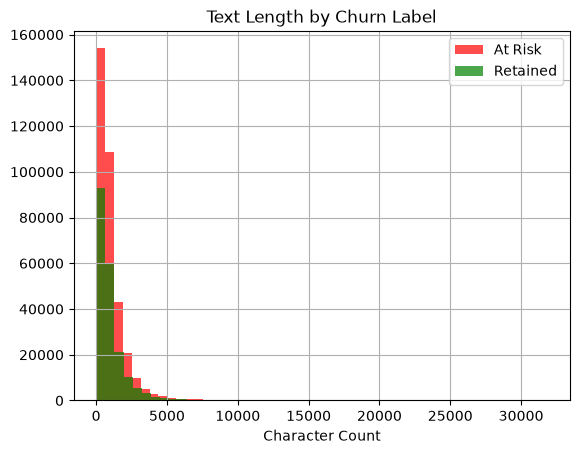

In [13]:
import matplotlib.pyplot as plt

df['TEXT_LENGTH'] = df['COMPLAINT_NARRATIVE'].str.len()
print(df['TEXT_LENGTH'].describe())

for label, color in zip(['At Risk', 'Retained'], ['red', 'green']):
    df[df['CHURN_LABEL'] == label]['TEXT_LENGTH'].hist(bins=50, alpha=0.7, label=label, color=color)

plt.title('Text Length by Churn Label')
plt.xlabel('Character Count')
plt.legend()
plt.savefig('../data/text_length_distribution.png')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert label to binary
df['LABEL'] = (df['CHURN_LABEL'] == 'At Risk').astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['COMPLAINT_NARRATIVE'], df['LABEL'],
    test_size=0.2, random_state=42, stratify=df['LABEL']
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train size: {X_train_tfidf.shape}")
print(f"Test size: {X_test_tfidf.shape}")

Train size: (439914, 10000)
Test size: (109979, 10000)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'At Risk']))

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['Retained', 'At Risk']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.50      0.70      0.58     39827
     At Risk       0.78      0.60      0.68     70152

    accuracy                           0.64    109979
   macro avg       0.64      0.65      0.63    109979
weighted avg       0.68      0.64      0.64    109979

=== Naive Bayes ===
              precision    recall  f1-score   support

    Retained       0.51      0.38      0.43     39827
     At Risk       0.69      0.79      0.74     70152

    accuracy                           0.64    109979
   macro avg       0.60      0.58      0.58    109979
weighted avg       0.62      0.64      0.63    109979



In [17]:
import joblib
import os

os.makedirs('../app', exist_ok=True)

# Save models and vectorizer
joblib.dump(nb, '../app/nb_model.pkl')
joblib.dump(lr, '../app/lr_model.pkl')
joblib.dump(tfidf, '../app/tfidf_vectorizer.pkl')

print("Models saved successfully!")

Models saved successfully!
